In [2]:
# --- CELL 1: SETUP AND INITIAL DATA EXPLORATION ---

# Import standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for all plots
sns.set_style("whitegrid")

# Load the dataset
# The dataset uses non-standard encoding, so we specify 'latin1'
try:
    df = pd.read_csv('data/superstore_sales_dataset.csv', encoding='latin1')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: Dataset file not found in the 'data' directory.")
    df = pd.DataFrame()

# Display initial information
if not df.empty:
    print("\n--- DataFrame Info ---")
    df.info()
    
    print("\n--- First 5 Rows ---")
    print(df.head())
    
    print("\n--- Statistical Summary ---")
    print(df.describe())

Dataset loaded successfully.

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17 

In [3]:
# --- CELL 2: DATA CLEANING & FEATURE ENGINEERING ---

# 1. Convert date columns to the correct datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)
print("Converted 'Order Date' and 'Ship Date' to datetime format.")

# 2. Handle missing values
df['Postal Code'].fillna(0, inplace=True)
df['Postal Code'] = df['Postal Code'].astype(int)
print("Filled missing 'Postal Code' values.")

# 3. Feature Engineering: Create new columns for deeper analysis
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
print("Created new columns: 'Order Year', 'Order Month'.")

# Display the first 5 rows to verify the changes
df.head()

Converted 'Order Date' and 'Ship Date' to datetime format.
Filled missing 'Postal Code' values.
Created new columns: 'Order Year', 'Order Month'.


/var/folders/1l/w0l2h4b54p9blc640vdwhzmh0000gn/T/ipykernel_47968/2167093421.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Postal Code'].fillna(0, inplace=True)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order Year,Order Month
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10


Total Sales by Customer Segment:
Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


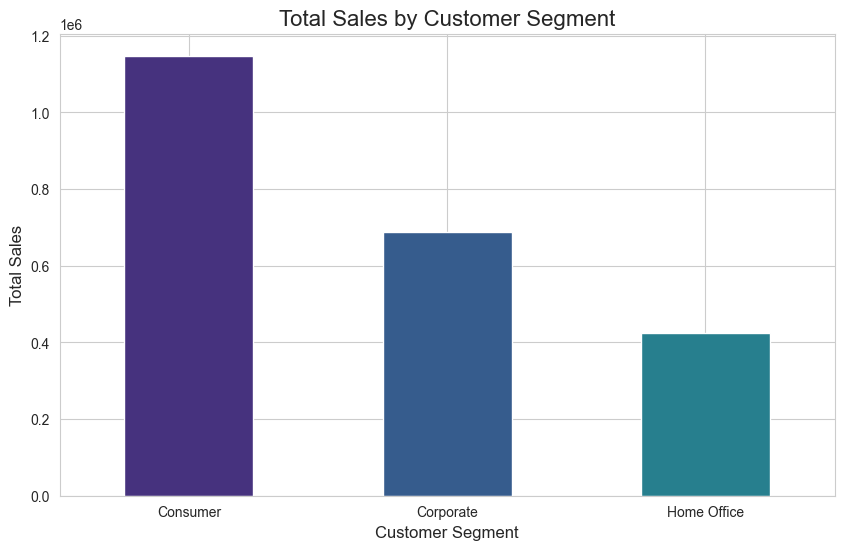

In [4]:
# --- CELL 3: SALES ANALYSIS BY CUSTOMER SEGMENT ---

# Group data by Segment and sum the Sales for each
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

print("Total Sales by Customer Segment:")
print(segment_sales)

# Plot the results
plt.figure(figsize=(10, 6))
segment_sales.plot(kind='bar', color=sns.color_palette('viridis'))
plt.title('Total Sales by Customer Segment', fontsize=16)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=0)
plt.show()

--- Total Sales by Main Category ---
Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


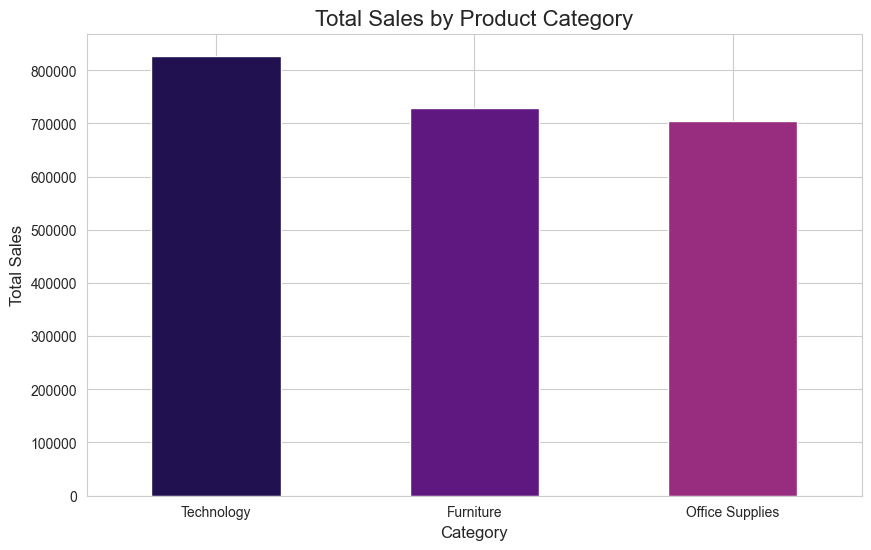


--- Total Sales by Sub-Category ---
Sub-Category
Fasteners        3001.9600
Labels          12347.7260
Envelopes       16128.0460
Art             26705.4100
Supplies        46420.3080
Paper           76828.3040
Furnishings     89212.0180
Appliances     104618.4030
Bookcases      113813.1987
Copiers        146248.0940
Accessories    164186.7000
Machines       189238.6310
Binders        200028.7850
Tables         202810.6280
Storage        219343.3920
Chairs         322822.7310
Phones         327782.4480
Name: Sales, dtype: float64


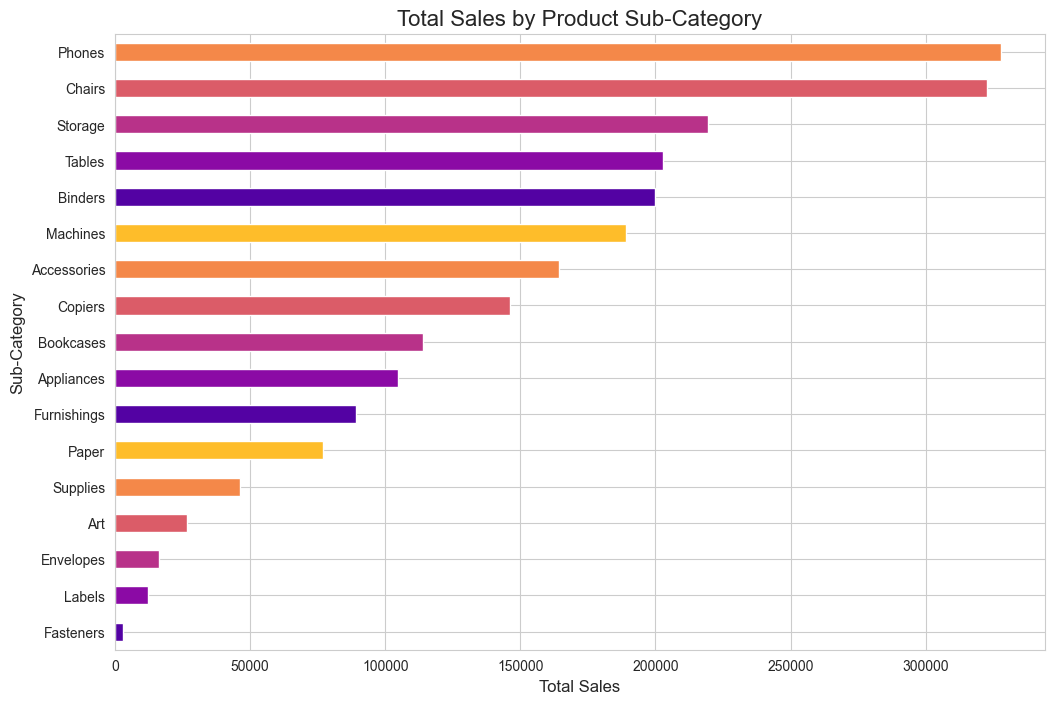

In [5]:
# --- CELL 4: SALES ANALYSIS BY PRODUCT CATEGORY ---

# Group by both Category and Sub-Category to get detailed insights
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print("--- Total Sales by Main Category ---")
print(category_sales)

plt.figure(figsize=(10, 6))
category_sales.plot(kind='bar', color=sns.color_palette('magma'))
plt.title('Total Sales by Product Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=0)
plt.show()

# --- Deeper Dive into Sub-Category ---
sub_category_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=True)

print("\n--- Total Sales by Sub-Category ---")
print(sub_category_sales)

plt.figure(figsize=(12, 8))
sub_category_sales.plot(kind='barh', color=sns.color_palette('plasma'))
plt.title('Total Sales by Product Sub-Category', fontsize=16)
plt.xlabel('Total Sales', fontsize=12)
plt.ylabel('Sub-Category', fontsize=12)
plt.show()

--- Total Sales by Year ---
Order Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64


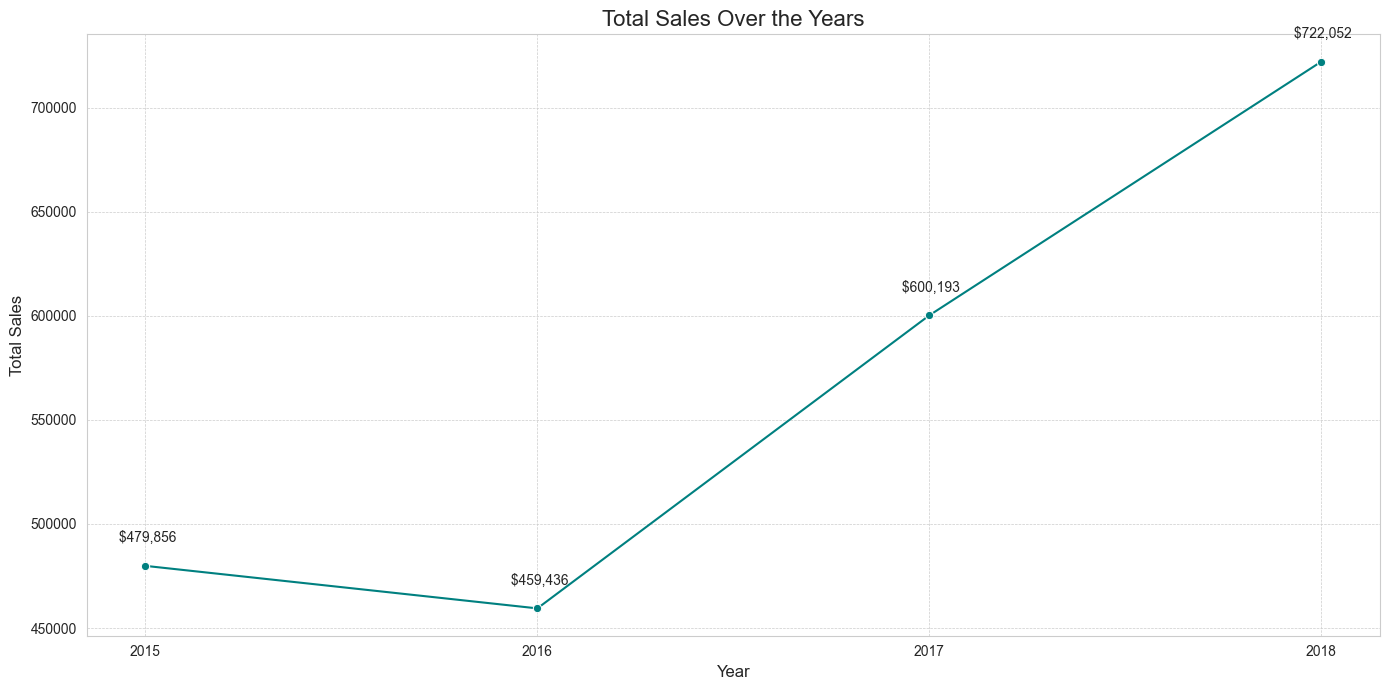

In [6]:
# --- CELL 5: SALES ANALYSIS BY YEAR (ENHANCED) ---

# Group by Order Year and sum the Sales
yearly_sales = df.groupby('Order Year')['Sales'].sum()

print("--- Total Sales by Year ---")
print(yearly_sales)

plt.figure(figsize=(14, 7))
line_plot = sns.lineplot(x=yearly_sales.index, y=yearly_sales.values, marker='o', color='teal')

plt.title('Total Sales Over the Years', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(yearly_sales.index)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Annotate the line plot with sales values
for index, value in yearly_sales.items():
    line_plot.text(index, value + 10000, f' ${value:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

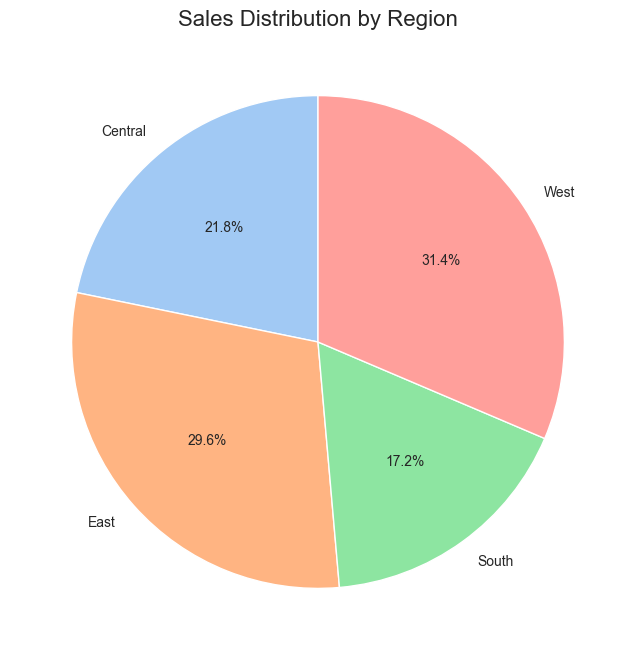

In [7]:
# --- CELL 6: SALES DISTRIBUTION BY REGION ---

region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(10, 8))
region_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))

plt.title('Sales Distribution by Region', fontsize=16)
plt.ylabel('') # Hide the y-axis label for pie charts
plt.show()